# Step 7 — Publication-Quality Figures (notebooks/07_final_figures.ipynb)

This notebook assembles the IEEE paper's hero figures and the master results
table. It consumes, without recomputing, the outputs of Steps 2–6 stored under
`experiments/results/` and the per-step figures already exported to
`report/figures/`.

**Inputs (read-only):**

- `experiments/results/{pd,hd,als}_results.json` — Step 2 within-condition.
- `experiments/results/cross_condition_results.json` — Step 3 transfer.
- `experiments/results/shap_results.json` — Step 4 SHAP δj.
- `experiments/results/noise_robustness.json` — Step 5 (optional panels).
- `data/processed/gait_features.csv` + `data/processed/control_partition.json` —
  used only to reproduce the Step 6 PCA fit for unified styling in Fig 5.

**Outputs:**

- Six paper figures under `report/figures/paper/{pdf,png}/` at IEEE
  single-column (3.5 in) or double-column (7.16 in) width:
  `fig1_within_overview`, `fig2_within_cms`, `fig3_cross_degradation`,
  `fig4_shap_delta_j`, `fig5_pca_kmeans`, `fig6_noise_robustness`.
- `report/tables/master_results.csv` and `report/tables/master_results.tex`
  (booktabs-style IEEE `tabular`).

No upstream artefact is modified. Missing optional inputs (Step 5 cross-noise
sweep) are skipped with a clear warning rather than failing the notebook.


In [1]:
import sys
import json
import warnings
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import polars as pl
import matplotlib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

from src.features import ALL_FEATURE_COLS

IEEE_SINGLE = 3.5
IEEE_DOUBLE = 7.16

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'figure.dpi': 180,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

PROCESSED = Path('../data/processed')
RESULTS = Path('../experiments/results')
PAPER_PDF = Path('../report/figures/paper/pdf')
PAPER_PNG = Path('../report/figures/paper/png')
TABLES = Path('../report/tables')
for d in (PAPER_PDF, PAPER_PNG, TABLES):
    d.mkdir(parents=True, exist_ok=True)

CLASSIFIERS = ['rf', 'knn', 'svm', 'dt', 'qda', 'xgb', 'lgbm']
CLF_LABEL = {
    'rf': 'RF', 'knn': 'KNN', 'svm': 'SVM', 'dt': 'DT',
    'qda': 'QDA', 'xgb': 'XGB', 'lgbm': 'LGBM',
}
CONDITIONS = ['pd', 'hd', 'als']
COND_LABEL = {'pd': 'PD', 'hd': 'HD', 'als': 'ALS'}
COND_COLORS = {'pd': '#1f77b4', 'hd': '#2ca02c', 'als': '#ff7f0e'}
DIRECTIONS = ['pd_to_hd', 'hd_to_pd', 'pd_to_als', 'als_to_pd', 'hd_to_als', 'als_to_hd']
DIR_LABEL = {d: d.replace('_to_', '→').upper() for d in DIRECTIONS}

def save_paper(fig, stem):
    pdf = PAPER_PDF / f'{stem}.pdf'
    png = PAPER_PNG / f'{stem}.png'
    fig.savefig(pdf)
    fig.savefig(png, dpi=300)
    print(f'  wrote {pdf.relative_to(Path(".."))} and {png.relative_to(Path(".."))}')

print('Setup complete.')


Setup complete.


In [2]:
def _load(path: Path, required: bool = True):
    if path.exists():
        with open(path) as f:
            return json.load(f)
    if required:
        raise FileNotFoundError(f'Required input missing: {path}')
    warnings.warn(f'Optional input missing: {path}')
    return None

within_results = {
    c: _load(RESULTS / f'{c}_results.json') for c in CONDITIONS
}
cross_results = _load(RESULTS / 'cross_condition_results.json')
shap_results = _load(RESULTS / 'shap_results.json')
noise_results = _load(RESULTS / 'noise_robustness.json', required=False)

gait_df = pl.read_csv(PROCESSED / 'gait_features.csv')

print(f'Within-condition loaded: {list(within_results)}')
print(f'Cross-condition directions: {list(cross_results)}')
print(f'SHAP directions: {list(shap_results)}')
print(f'Noise robustness present: {noise_results is not None}')
print(f'Gait feature matrix: {gait_df.shape}')


Within-condition loaded: ['pd', 'hd', 'als']
Cross-condition directions: ['pd_to_hd', 'hd_to_pd', 'pd_to_als', 'als_to_pd', 'hd_to_als', 'als_to_hd']
SHAP directions: ['als_to_pd', 'als_to_hd', 'pd_to_als', 'pd_to_hd', 'hd_to_als', 'hd_to_pd']
Noise robustness present: True
Gait feature matrix: (14753, 17)


## Figure 1 — Within-condition overview

Composite 1×2 panel: (left) F1-macro heatmap across classifiers × conditions
from Step 2 LOSO-CV; (right) modal-parameter frequency heatmap indicating how
consistently the selected modal hyperparameters win across LOSO folds. A
single-column variant contains only the F1 heatmap for a tight paper layout.


  wrote report/figures/paper/pdf/fig1_within_overview.pdf and report/figures/paper/png/fig1_within_overview.png


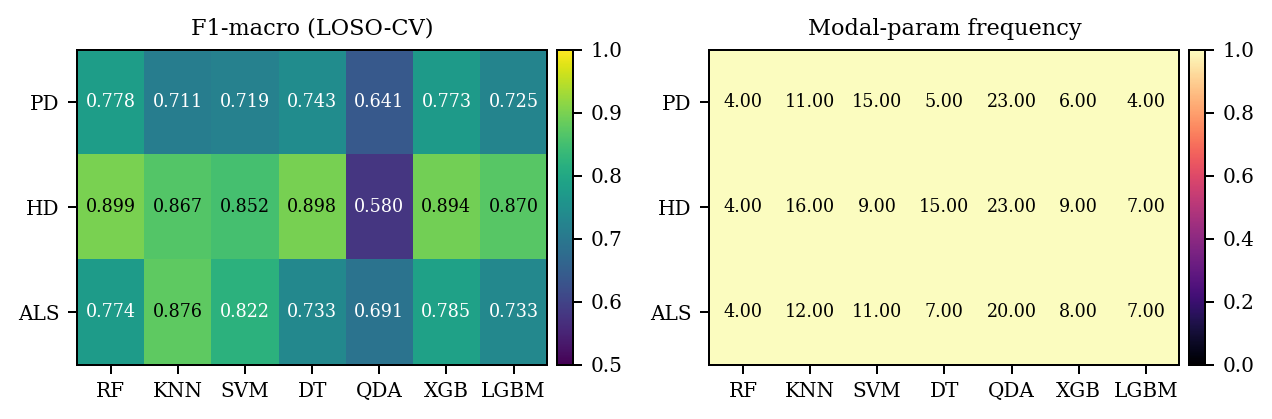

  wrote report/figures/paper/pdf/fig1_within_f1_single.pdf and report/figures/paper/png/fig1_within_f1_single.png


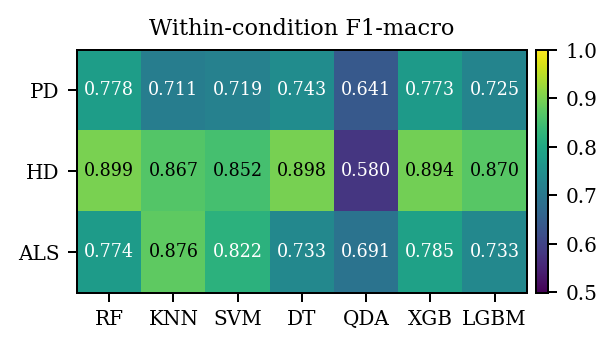

In [3]:
f1_matrix = np.array([
    [within_results[c]['classifiers'][clf]['f1_macro'] for clf in CLASSIFIERS]
    for c in CONDITIONS
])
mf_matrix = np.array([
    [within_results[c]['classifiers'][clf].get('modal_frequency', np.nan) for clf in CLASSIFIERS]
    for c in CONDITIONS
])

def _heatmap(ax, values, vmin, vmax, cmap, title, fmt='{:.3f}'):
    im = ax.imshow(values, vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(CLASSIFIERS)))
    ax.set_xticklabels([CLF_LABEL[c] for c in CLASSIFIERS])
    ax.set_yticks(range(len(CONDITIONS)))
    ax.set_yticklabels([COND_LABEL[c] for c in CONDITIONS])
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            v = values[i, j]
            if np.isnan(v):
                continue
            bg = im.cmap(im.norm(v))[:3]
            lum = 0.299*bg[0] + 0.587*bg[1] + 0.114*bg[2]
            ax.text(j, i, fmt.format(v), ha='center', va='center',
                    fontsize=7, color='black' if lum > 0.55 else 'white')
    return im

fig, axes = plt.subplots(1, 2, figsize=(IEEE_DOUBLE, 2.4))
im1 = _heatmap(axes[0], f1_matrix, 0.5, 1.0, 'viridis', 'F1-macro (LOSO-CV)')
im2 = _heatmap(axes[1], mf_matrix, 0.0, 1.0, 'magma', 'Modal-param frequency', fmt='{:.2f}')
fig.colorbar(im1, ax=axes[0], fraction=0.05, pad=0.02)
fig.colorbar(im2, ax=axes[1], fraction=0.05, pad=0.02)
fig.tight_layout()
save_paper(fig, 'fig1_within_overview')
plt.show()

fig, ax = plt.subplots(figsize=(IEEE_SINGLE, 2.0))
im = _heatmap(ax, f1_matrix, 0.5, 1.0, 'viridis', 'Within-condition F1-macro')
fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
fig.tight_layout()
save_paper(fig, 'fig1_within_f1_single')
plt.show()


## Figure 2 — Within-condition confusion matrices

Row of normalised confusion matrices for the modal-best classifier per
condition (PD–RF, HD–RF, ALS–KNN, as established in Step 2). Single shared
colourbar; no recomputation — plotted directly from the stored
`y_true`/`y_pred` lists.


  wrote report/figures/paper/pdf/fig2_within_cms.pdf and report/figures/paper/png/fig2_within_cms.png


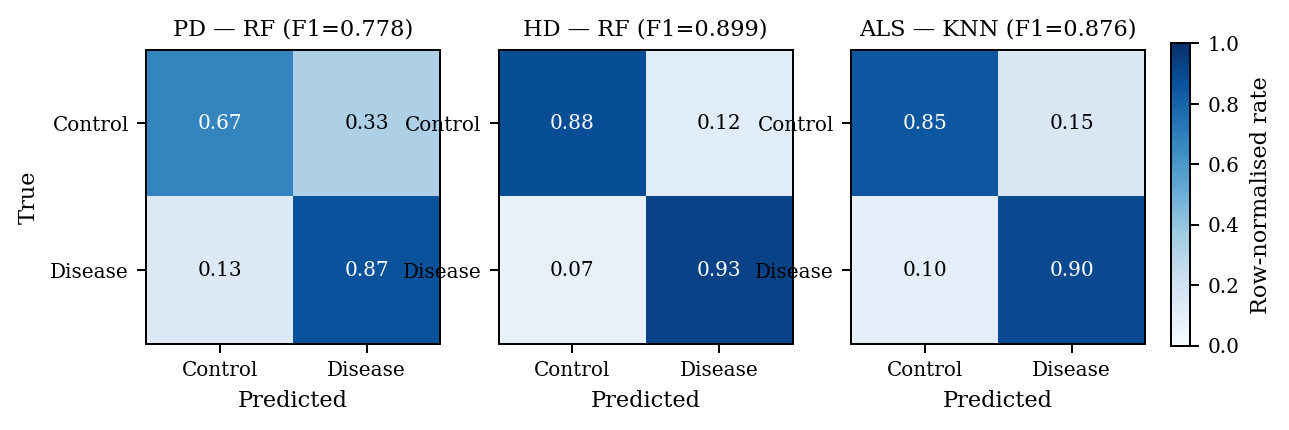

In [4]:
BEST = [('pd', 'rf'), ('hd', 'rf'), ('als', 'knn')]

fig, axes = plt.subplots(1, 3, figsize=(IEEE_DOUBLE, 2.4))
ims = []
for ax, (cond, clf) in zip(axes, BEST):
    entry = within_results[cond]['classifiers'][clf]
    y_true = np.asarray(entry['y_true'])
    y_pred = np.asarray(entry['y_pred'])
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, vmin=0, vmax=1, cmap='Blues')
    ims.append(im)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Control', 'Disease'])
    ax.set_yticklabels(['Control', 'Disease'])
    ax.set_xlabel('Predicted')
    if ax is axes[0]:
        ax.set_ylabel('True')
    ax.set_title(f'{COND_LABEL[cond]} — {CLF_LABEL[clf]} (F1={entry["f1_macro"]:.3f})')
    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            lum = 0.299 + 0.587*(1-v) + 0.114*(1-v)
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if v < 0.5 else 'white')

fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(ims[-1], cax=cbar_ax, label='Row-normalised rate')
save_paper(fig, 'fig2_within_cms')
plt.show()


## Figure 3 — Cross-condition transfer

Top: per-classifier ΔF1 heatmap across the six transfer directions (positive
= cross ≥ within, negative = degradation). Bottom: grouped within vs. cross
F1 bars with stride-level 95% CIs. Both panels assembled from
`cross_condition_results.json` (F1 and CI) and within-condition baselines in
`{cond}_results.json` (F1 only).


  wrote report/figures/paper/pdf/fig3_cross_degradation.pdf and report/figures/paper/png/fig3_cross_degradation.png


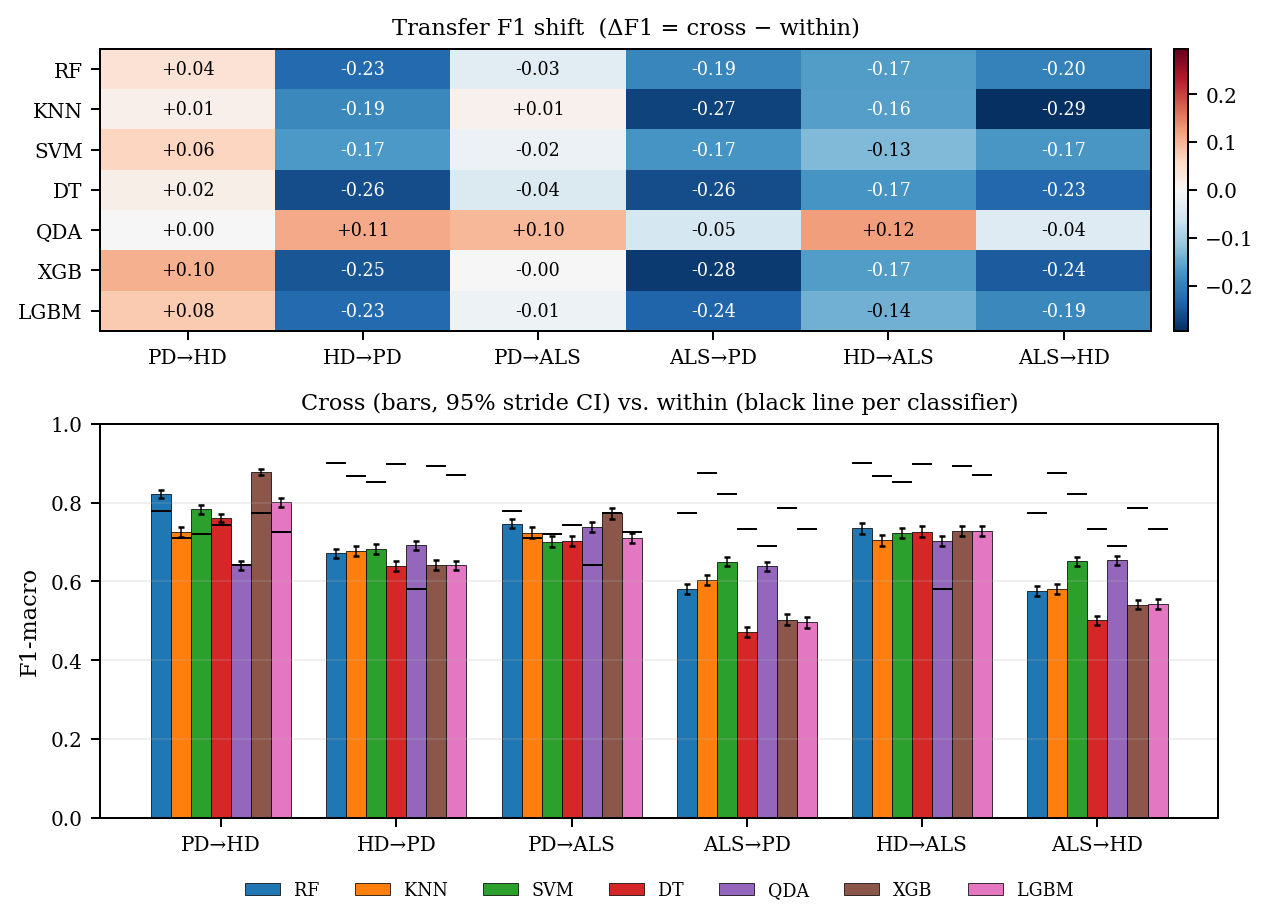

In [5]:
delta_f1 = np.zeros((len(CLASSIFIERS), len(DIRECTIONS)))
within_f1 = np.zeros_like(delta_f1)
cross_f1 = np.zeros_like(delta_f1)
cross_ci_lo = np.zeros_like(delta_f1)
cross_ci_hi = np.zeros_like(delta_f1)

for j, direction in enumerate(DIRECTIONS):
    src = direction.split('_to_')[0]
    for i, clf in enumerate(CLASSIFIERS):
        wf = within_results[src]['classifiers'][clf]['f1_macro']
        cf_entry = cross_results[direction]['classifiers'][clf]
        cf = cf_entry['f1_macro']
        within_f1[i, j] = wf
        cross_f1[i, j] = cf
        delta_f1[i, j] = cf - wf
        cross_ci_lo[i, j] = cf_entry.get('f1_macro_ci_lower', cf)
        cross_ci_hi[i, j] = cf_entry.get('f1_macro_ci_upper', cf)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(IEEE_DOUBLE, 5.2),
                                     gridspec_kw={'height_ratios': [1, 1.4]})

vmax = np.nanmax(np.abs(delta_f1))
im = ax_top.imshow(delta_f1, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax_top.set_xticks(range(len(DIRECTIONS)))
ax_top.set_xticklabels([DIR_LABEL[d] for d in DIRECTIONS], rotation=0)
ax_top.set_yticks(range(len(CLASSIFIERS)))
ax_top.set_yticklabels([CLF_LABEL[c] for c in CLASSIFIERS])
ax_top.set_title('Transfer F1 shift  (ΔF1 = cross − within)')
for i in range(delta_f1.shape[0]):
    for j in range(delta_f1.shape[1]):
        v = delta_f1[i, j]
        ax_top.text(j, i, f'{v:+.2f}', ha='center', va='center',
                    fontsize=7, color='black' if abs(v) < vmax*0.5 else 'white')
fig.colorbar(im, ax=ax_top, fraction=0.04, pad=0.02)

width = 0.8 / len(CLASSIFIERS)
x = np.arange(len(DIRECTIONS))
cmap_bar = plt.get_cmap('tab10')
for i, clf in enumerate(CLASSIFIERS):
    offs = (i - (len(CLASSIFIERS) - 1)/2) * width
    err_lo = cross_f1[i] - cross_ci_lo[i]
    err_hi = cross_ci_hi[i] - cross_f1[i]
    ax_bot.bar(x + offs, cross_f1[i], width=width,
               color=cmap_bar(i), edgecolor='k', linewidth=0.3,
               label=CLF_LABEL[clf],
               yerr=np.stack([err_lo, err_hi]), capsize=1.2,
               error_kw={'elinewidth': 0.6})
    for j in range(len(DIRECTIONS)):
        ax_bot.hlines(within_f1[i, j], x[j] + offs - width/2, x[j] + offs + width/2,
                      colors='k', linewidths=0.8)

ax_bot.set_xticks(x)
ax_bot.set_xticklabels([DIR_LABEL[d] for d in DIRECTIONS])
ax_bot.set_ylabel('F1-macro')
ax_bot.set_ylim(0, 1.0)
ax_bot.set_title('Cross (bars, 95% stride CI) vs. within (black line per classifier)')
ax_bot.legend(ncol=7, loc='upper center', bbox_to_anchor=(0.5, -0.12), frameon=False)
ax_bot.grid(axis='y', alpha=0.2)

fig.tight_layout()
save_paper(fig, 'fig3_cross_degradation')
plt.show()


## Figure 4 — SHAP δj diagnosis (Step 4)

Left: normalised δj heatmap for RF across the six transfer directions,
highlighting which features shift in attribution between within- and
cross-condition predictions. Right: top-3 δj features per direction as a
compact table panel, extracted from `shap_results.json`.


  wrote report/figures/paper/pdf/fig4_shap_delta_j.pdf and report/figures/paper/png/fig4_shap_delta_j.png


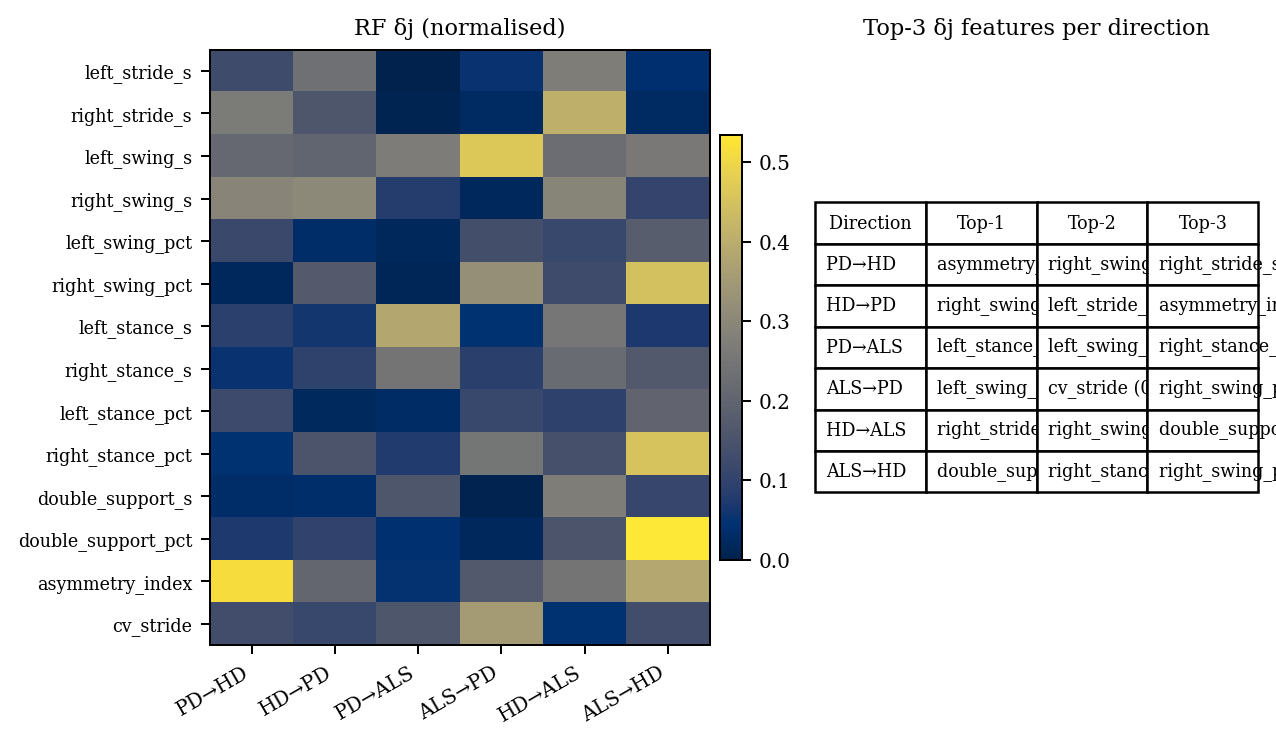

In [6]:
features = ALL_FEATURE_COLS

def _delta_map(direction, clf='rf', key='delta_j_normalized'):
    raw = shap_results[direction][clf][key]
    if isinstance(raw, dict):
        return {f: float(raw.get(f, np.nan)) for f in features}
    return {f: float(v) for f, v in zip(features, raw)}

delta_mat = np.zeros((len(features), len(DIRECTIONS)))
for j, direction in enumerate(DIRECTIONS):
    dj = _delta_map(direction)
    for i, feat in enumerate(features):
        delta_mat[i, j] = dj.get(feat, np.nan)

top3_rows = []
for direction in DIRECTIONS:
    dj = _delta_map(direction)
    ranked = sorted(dj.items(), key=lambda kv: -kv[1])[:3]
    top3_rows.append([DIR_LABEL[direction]] + [f'{f} ({v:.2f})' for f, v in ranked])
top3_df = pd.DataFrame(top3_rows, columns=['Direction', 'Top-1', 'Top-2', 'Top-3'])

fig, (ax_hm, ax_tb) = plt.subplots(1, 2, figsize=(IEEE_DOUBLE, 4.2),
                                    gridspec_kw={'width_ratios': [1.2, 1.0]})

vmax = np.nanmax(delta_mat)
im = ax_hm.imshow(delta_mat, cmap='cividis', vmin=0, vmax=vmax, aspect='auto')
ax_hm.set_xticks(range(len(DIRECTIONS)))
ax_hm.set_xticklabels([DIR_LABEL[d] for d in DIRECTIONS], rotation=30, ha='right')
ax_hm.set_yticks(range(len(features)))
ax_hm.set_yticklabels(features, fontsize=7)
ax_hm.set_title('RF δj (normalised)')
fig.colorbar(im, ax=ax_hm, fraction=0.04, pad=0.02)

ax_tb.axis('off')
table = ax_tb.table(cellText=top3_df.values, colLabels=list(top3_df.columns),
                    cellLoc='left', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1.0, 1.35)
ax_tb.set_title('Top-3 δj features per direction')

fig.tight_layout()
save_paper(fig, 'fig4_shap_delta_j')
plt.show()


## Figure 5 — PCA + K-Means unified view (Step 6)

The PCA fit is reproduced here with Step-6-identical settings so the styling
matches the rest of the paper. Left: PC1 vs. PC2 coloured by condition.
Right: K-Means (K=3) cluster overlay. Bottom strip: cumulative explained
variance.


  wrote report/figures/paper/pdf/fig5_pca_kmeans.pdf and report/figures/paper/png/fig5_pca_kmeans.png


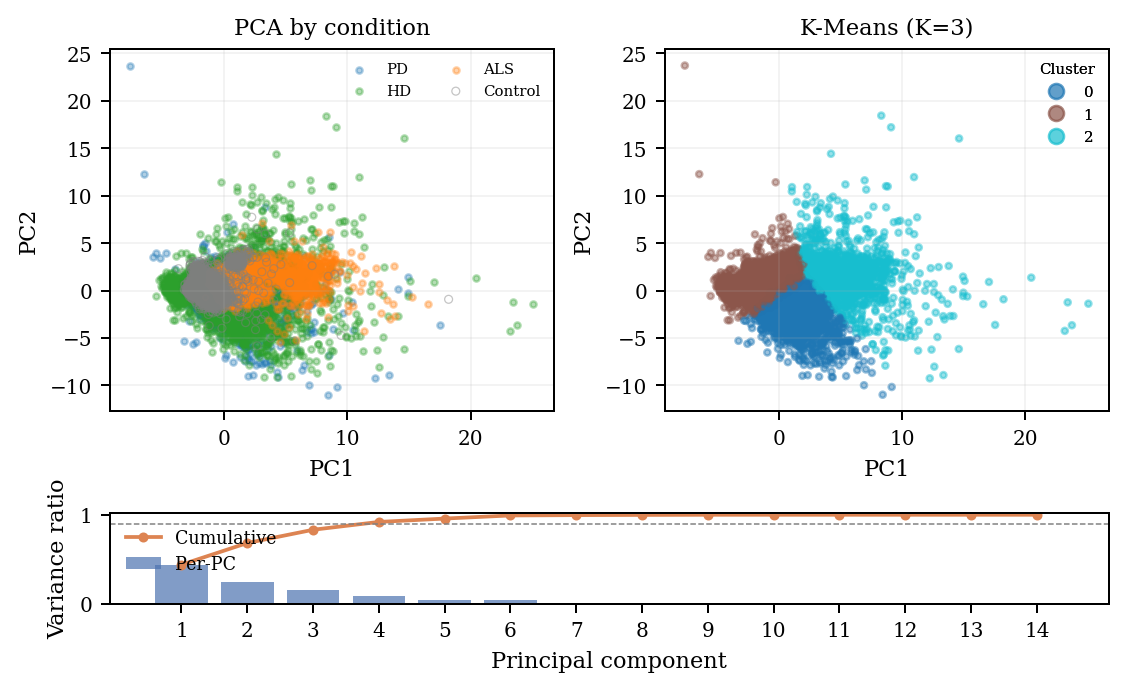

In [7]:
X = gait_df.select(ALL_FEATURE_COLS).to_numpy()
conditions_arr = gait_df['condition'].to_numpy()
labels_arr = gait_df['label'].to_numpy()

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=len(ALL_FEATURE_COLS), random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

COND_ORDER = ['pd', 'hd', 'als', 'control']
COND_LABELS_FULL = {'pd': 'PD', 'hd': 'HD', 'als': 'ALS', 'control': 'Control'}
COND_COLORS_FULL = {'pd': '#1f77b4', 'hd': '#2ca02c', 'als': '#ff7f0e', 'control': '#7f7f7f'}

fig = plt.figure(figsize=(IEEE_DOUBLE, 4.0))
gs = fig.add_gridspec(2, 2, height_ratios=[4, 1], hspace=0.45, wspace=0.25)
ax_cond = fig.add_subplot(gs[0, 0])
ax_clust = fig.add_subplot(gs[0, 1])
ax_var = fig.add_subplot(gs[1, :])

for cond in COND_ORDER:
    mask = conditions_arr == cond
    if not mask.any():
        continue
    disease = (labels_arr == 1) & mask
    control = (labels_arr == 0) & mask
    ax_cond.scatter(X_pca[disease, 0], X_pca[disease, 1], s=6, alpha=0.35,
                    color=COND_COLORS_FULL[cond], marker='o',
                    label=f'{COND_LABELS_FULL[cond]}' if cond != 'control' else None)
    ax_cond.scatter(X_pca[control, 0], X_pca[control, 1], s=10, alpha=0.45,
                    facecolors='none', edgecolors=COND_COLORS_FULL[cond],
                    linewidths=0.5, marker='o',
                    label='Control' if cond == 'control' else None)
ax_cond.set_xlabel('PC1'); ax_cond.set_ylabel('PC2')
ax_cond.set_title('PCA by condition')
ax_cond.legend(loc='best', frameon=False, fontsize=6, ncol=2)
ax_cond.grid(alpha=0.15)

scat = ax_clust.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10',
                        s=6, alpha=0.45)
ax_clust.set_xlabel('PC1'); ax_clust.set_ylabel('PC2')
ax_clust.set_title('K-Means (K=3)')
ax_clust.grid(alpha=0.15)
legend = ax_clust.legend(*scat.legend_elements(), title='Cluster',
                         loc='best', fontsize=6, title_fontsize=6, frameon=False)
ax_clust.add_artist(legend)

cum = np.cumsum(pca.explained_variance_ratio_)
comps = np.arange(1, len(cum) + 1)
ax_var.bar(comps, pca.explained_variance_ratio_, color='#4c72b0', alpha=0.7,
           label='Per-PC')
ax_var.plot(comps, cum, marker='o', ms=3, color='#dd8452', label='Cumulative')
ax_var.axhline(0.9, color='gray', linestyle='--', linewidth=0.6)
ax_var.set_xlabel('Principal component')
ax_var.set_ylabel('Variance ratio')
ax_var.set_xticks(comps)
ax_var.set_ylim(0, 1.02)
ax_var.legend(loc='upper left', frameon=False, fontsize=7)

save_paper(fig, 'fig5_pca_kmeans')
plt.show()


## Figure 6 — Noise robustness (Step 5, within-condition)

F1-macro vs Gaussian input noise σ for each classifier, per condition. Clean
baseline (σ=0) is a single point; σ∈{0.05…0.50} have 30 repeats — plotted as
mean with ±1 SD shading. Cross-condition sweep is omitted (empty in the
current `noise_robustness.json`).


  wrote report/figures/paper/pdf/fig6_noise_robustness.pdf and report/figures/paper/png/fig6_noise_robustness.png


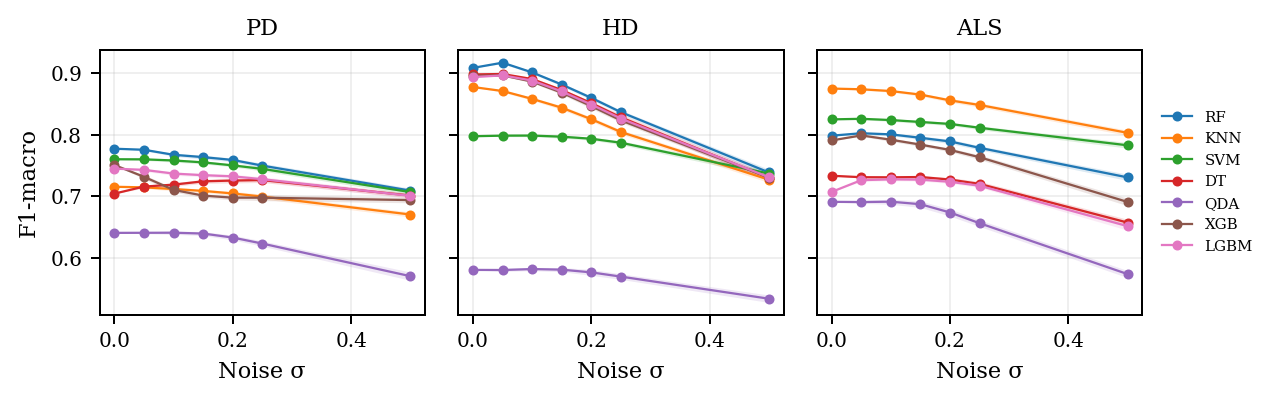

Cross-condition noise sweep is empty in noise_robustness.json; not plotted.


In [8]:
if noise_results is None:
    print('noise_robustness.json missing — skipping Fig 6.')
else:
    sigma_keys = ['0.0', '0.05', '0.1', '0.15', '0.2', '0.25', '0.5']
    sigmas = np.array([float(s) for s in sigma_keys])

    fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(IEEE_DOUBLE, 2.3), sharey=True)
    cmap_line = plt.get_cmap('tab10')
    for ax, cond in zip(axes, CONDITIONS):
        for i, clf in enumerate(CLASSIFIERS):
            if clf not in noise_results['within'][cond]:
                continue
            per_sigma = noise_results['within'][cond][clf]
            means, stds = [], []
            for sk in sigma_keys:
                vals = np.asarray(per_sigma.get(sk, []), dtype=float)
                if vals.size == 0:
                    means.append(np.nan); stds.append(0.0)
                else:
                    means.append(vals.mean()); stds.append(vals.std(ddof=1) if vals.size > 1 else 0.0)
            means = np.asarray(means); stds = np.asarray(stds)
            ax.plot(sigmas, means, marker='o', ms=3, linewidth=0.9,
                    color=cmap_line(i), label=CLF_LABEL[clf])
            ax.fill_between(sigmas, means - stds, means + stds,
                            color=cmap_line(i), alpha=0.15, linewidth=0)
        ax.set_xlabel('Noise σ')
        ax.set_title(COND_LABEL[cond])
        ax.grid(alpha=0.2)
    axes[0].set_ylabel('F1-macro')
    axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                    frameon=False, fontsize=6)
    fig.tight_layout()
    save_paper(fig, 'fig6_noise_robustness')
    plt.show()

    empty_cross = all(not noise_results['cross'][d] for d in noise_results['cross'])
    if empty_cross:
        print('Cross-condition noise sweep is empty in noise_robustness.json; not plotted.')


## Master results table

Single long-form table with one row per (direction, classifier) carrying the
within-condition F1 baseline, cross-condition F1 with both stride- and
subject-level 95% CIs, permutation p-value, ΔF1, and the top-1 δj feature
(RF-normalised). Emitted to CSV and to an IEEE booktabs `tabular` for
inclusion in the paper.


In [9]:
def _delta_map_master(direction, clf='rf', key='delta_j_normalized'):
    raw = shap_results[direction][clf][key]
    if isinstance(raw, dict):
        return {f: float(raw.get(f, np.nan)) for f in ALL_FEATURE_COLS}
    return {f: float(v) for f, v in zip(ALL_FEATURE_COLS, raw)}

rows = []
for direction in DIRECTIONS:
    src = direction.split('_to_')[0]
    top1_feat = None
    if direction in shap_results:
        dj = _delta_map_master(direction)
        top1_feat = max(dj.items(), key=lambda kv: kv[1])[0]
    for clf in CLASSIFIERS:
        within_f1 = within_results[src]['classifiers'][clf]['f1_macro']
        cf_entry = cross_results[direction]['classifiers'][clf]
        rows.append({
            'direction': DIR_LABEL[direction],
            'classifier': CLF_LABEL[clf],
            'within_f1': round(within_f1, 4),
            'cross_f1': round(cf_entry['f1_macro'], 4),
            'delta_f1': round(cf_entry['f1_macro'] - within_f1, 4),
            'stride_ci_low': round(cf_entry.get('f1_macro_ci_lower', np.nan), 4),
            'stride_ci_high': round(cf_entry.get('f1_macro_ci_upper', np.nan), 4),
            'subj_ci_low': round(cf_entry.get('f1_macro_subj_ci_lower', np.nan), 4),
            'subj_ci_high': round(cf_entry.get('f1_macro_subj_ci_upper', np.nan), 4),
            'perm_p': round(cf_entry.get('permutation_p_value', np.nan), 4),
            'top1_delta_j_feature': top1_feat,
        })
master_df = pd.DataFrame(rows)
csv_path = TABLES / 'master_results.csv'
master_df.to_csv(csv_path, index=False)
print(f'Wrote {csv_path.relative_to(Path(".."))}  ({len(master_df)} rows).')

def _tex_escape(s):
    if s is None:
        return '--'
    return str(s).replace('_', r'\_').replace('→', r'$\rightarrow$')

tex_lines = [
    r'% Auto-generated by notebooks/07_final_figures.ipynb',
    r'\begin{tabular}{llrrrrrrr}',
    r'\toprule',
    r'Direction & Clf & Within F1 & Cross F1 & $\Delta$F1 & Stride CI & Subj CI & $p$ & Top-1 $\delta_j$ \\',
    r'\midrule',
]
current_dir = None
for _, r in master_df.iterrows():
    if r['direction'] != current_dir and current_dir is not None:
        tex_lines.append(r'\addlinespace')
    current_dir = r['direction']
    tex_lines.append(
        f"{_tex_escape(r['direction'])} & {_tex_escape(r['classifier'])} & "
        f"{r['within_f1']:.3f} & {r['cross_f1']:.3f} & {r['delta_f1']:+.3f} & "
        f"[{r['stride_ci_low']:.3f},{r['stride_ci_high']:.3f}] & "
        f"[{r['subj_ci_low']:.3f},{r['subj_ci_high']:.3f}] & "
        f"{r['perm_p']:.3f} & {_tex_escape(r['top1_delta_j_feature'])} \\\\"
    )
tex_lines += [r'\bottomrule', r'\end{tabular}']
tex_path = TABLES / 'master_results.tex'
tex_path.write_text('\n'.join(tex_lines) + '\n')
print(f'Wrote {tex_path.relative_to(Path(".."))}')

display(master_df.head(14))


Wrote report/tables/master_results.csv  (42 rows).
Wrote report/tables/master_results.tex


,direction,classifier,within_f1,cross_f1,delta_f1,stride_ci_low,stride_ci_high,subj_ci_low,subj_ci_high,perm_p,top1_delta_j_feature
0,PD→HD,RF,0.7777,0.8208,0.0431,0.8108,0.8309,0.6676,0.9141,0.0,asymmetry_index
1,PD→HD,KNN,0.7110,0.7260,0.0150,0.7135,0.7384,0.5777,0.8310,0.0,asymmetry_index
2,PD→HD,SVM,0.7194,0.7829,0.0636,0.7715,0.7948,0.6161,0.8993,0.0,asymmetry_index
3,PD→HD,DT,0.7434,0.7609,0.0174,0.7496,0.7721,0.5733,0.8851,0.0,asymmetry_index
4,PD→HD,QDA,0.6406,0.6414,0.0008,0.6296,0.6522,0.4923,0.7650,0.0,asymmetry_index
5,PD→HD,XGB,0.7727,0.8773,0.1046,0.8689,0.8858,0.7450,0.9600,0.0,asymmetry_index
6,PD→HD,LGBM,0.7251,0.8011,0.0760,0.7893,0.8122,0.6195,0.9185,0.0,asymmetry_index
7,HD→PD,RF,0.8995,0.6707,-0.2288,0.6582,0.6831,0.4662,0.8451,0.0,right_swing_s
8,HD→PD,KNN,0.8669,0.6775,-0.1895,0.6656,0.6899,0.4828,0.8270,0.0,right_swing_s
9,HD→PD,SVM,0.8524,0.6825,-0.1699,0.6696,0.6950,0.4895,0.8436,0.0,right_swing_s


## Verification

Sanity checks: every paper figure + both table files are present on disk,
F1 values round-trip back to the source JSONs with machine precision, and the
CSV row count matches the number of (direction × classifier) pairs.


In [10]:
expected_figs = [
    'fig1_within_overview', 'fig1_within_f1_single', 'fig2_within_cms',
    'fig3_cross_degradation', 'fig4_shap_delta_j', 'fig5_pca_kmeans',
]
if noise_results is not None:
    expected_figs.append('fig6_noise_robustness')

for stem in expected_figs:
    for ext, d in [('pdf', PAPER_PDF), ('png', PAPER_PNG)]:
        assert (d / f'{stem}.{ext}').exists(), f'missing {d / (stem + "." + ext)}'

for p in [TABLES / 'master_results.csv', TABLES / 'master_results.tex']:
    assert p.exists() and p.stat().st_size > 0, f'missing or empty: {p}'

reloaded = pd.read_csv(TABLES / 'master_results.csv')
assert len(reloaded) == len(DIRECTIONS) * len(CLASSIFIERS)

for direction in DIRECTIONS:
    src = direction.split('_to_')[0]
    for clf in CLASSIFIERS:
        row = reloaded[(reloaded['direction'] == DIR_LABEL[direction]) &
                       (reloaded['classifier'] == CLF_LABEL[clf])].iloc[0]
        json_within = within_results[src]['classifiers'][clf]['f1_macro']
        json_cross = cross_results[direction]['classifiers'][clf]['f1_macro']
        assert abs(row['within_f1'] - round(json_within, 4)) < 1e-6
        assert abs(row['cross_f1'] - round(json_cross, 4)) < 1e-6

print('All verifications passed.')
print(f'  {len(expected_figs)} figure stems × (pdf + png) present in report/figures/paper/.')
print(f'  {len(reloaded)} master-table rows round-trip to JSON.')


All verifications passed.
  7 figure stems × (pdf + png) present in report/figures/paper/.
  42 master-table rows round-trip to JSON.
